<a href="https://colab.research.google.com/github/srinugrandhi1729/Cayley-Hamilton-verifier-tool/blob/main/Cayley_Hamilton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# CAYLEY-HAMILTON VERIFIER TOOL (C7)
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import time

# -------- INPUT MATRIX --------
A = sp.Matrix([
    [2, 1],
    [1, 2]
])

POWER = 8
n = A.rows
I = sp.eye(n)
x = sp.symbols('x')

print("=" * 60)
print("CAYLEY-HAMILTON VERIFIER TOOL")
print("=" * 60)

print("\nINPUT MATRIX A:")
sp.pprint(A)

# -------- CHARACTERISTIC EQUATION --------
poly = A.charpoly(x)
coeff = poly.all_coeffs()

print("\n1. CHARACTERISTIC EQUATION:")
sp.pprint(poly.as_expr())

# -------- CAYLEY-HAMILTON VERIFICATION --------
pA = sp.zeros(n)

for i in range(len(coeff)):
    power = n - i

    if power == 0:
        pA += coeff[i] * I
    else:
        pA += coeff[i] * (A ** power)

print("\n2. p(A):")
sp.pprint(pA)

if pA == sp.zeros(n):
    print("✓ Cayley-Hamilton Verified")
else:
    print("✗ Verification Failed")

# -------- INVERSE USING C-H --------
print("\n3. A^-1 USING C-H:")

c0 = coeff[-1]

if c0 != 0:

    expression = sp.zeros(n)

    for i in range(len(coeff) - 1):
        power = n - 1 - i

        if power == 0:
            expression += coeff[i] * I
        else:
            expression += coeff[i] * (A ** power)

    A_inverse = -expression / c0

    sp.pprint(A_inverse)

else:
    print("Inverse cannot be calculated using this formula.")

# -------- A^8 USING C-H --------
# For this project we reduce powers using the characteristic equation.

def cayley_hamilton_power(A, power):

    n = A.rows
    x = sp.symbols('x')
    coeff = A.charpoly(x).all_coeffs()

    P = [sp.eye(n)]

    # A^1, A^2, ... A^(n-1)
    for k in range(1, n):
        P.append(A ** k)

    # Higher powers
    for k in range(n, power + 1):

        result = sp.zeros(n)

        for j in range(1, n + 1):
            result += coeff[j] * P[k - j]

        P.append(-result)

    return P[power]


start = time.perf_counter()

A8_CH = cayley_hamilton_power(A, POWER)

ch_time = time.perf_counter() - start

print("\n4. A^8 USING CAYLEY-HAMILTON:")
sp.pprint(A8_CH)

# -------- DIRECT A^8 --------
start = time.perf_counter()

A8_direct = A ** POWER

direct_time = time.perf_counter() - start

print("\n5. A^8 USING DIRECT METHOD:")
sp.pprint(A8_direct)

# -------- COMPARISON --------
print("\n6. COMPARISON:")

if A8_CH == A8_direct:
    print("✓ Both results are SAME")
else:
    print("✗ Results are DIFFERENT")

print("\n7. TIME:")
print("Cayley-Hamilton :", ch_time)
print("Direct Method   :", direct_time)

CAYLEY-HAMILTON VERIFIER TOOL

INPUT MATRIX A:
⎡2  1⎤
⎢    ⎥
⎣1  2⎦

1. CHARACTERISTIC EQUATION:
 2          
x  - 4⋅x + 3

2. p(A):
⎡0  0⎤
⎢    ⎥
⎣0  0⎦
✓ Cayley-Hamilton Verified

3. A^-1 USING C-H:
⎡2/3   -1/3⎤
⎢          ⎥
⎣-1/3  2/3 ⎦

4. A^8 USING CAYLEY-HAMILTON:
⎡3281  3280⎤
⎢          ⎥
⎣3280  3281⎦

5. A^8 USING DIRECT METHOD:
⎡3281  3280⎤
⎢          ⎥
⎣3280  3281⎦

6. COMPARISON:
✓ Both results are SAME

7. TIME:
Cayley-Hamilton : 0.0022492289999718196
Direct Method   : 0.001099447000001419



BENCHMARK TEST
Test 1: ✓ Passed
Test 2: ✓ Passed
Test 3: ✓ Passed


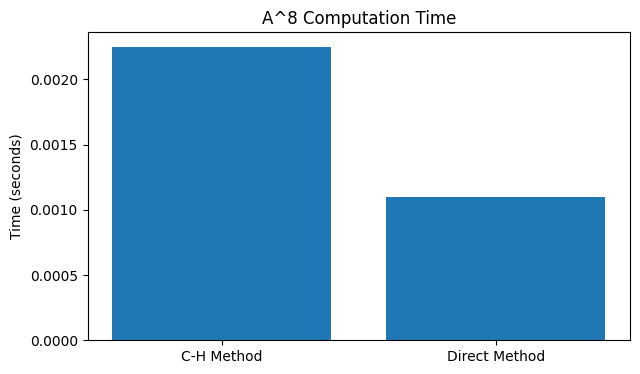

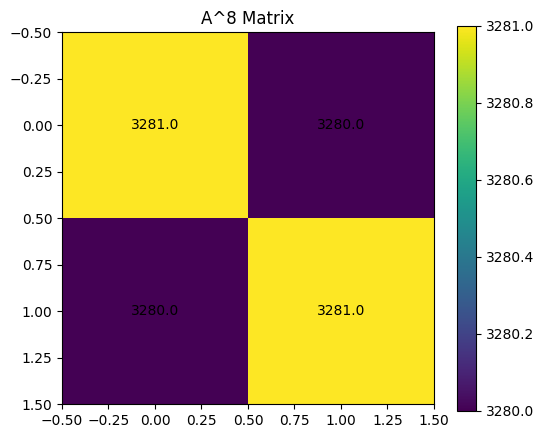


FINAL RESULT
✓ Characteristic equation
✓ Cayley-Hamilton verification
✓ A^-1 using C-H
✓ A^8 using C-H
✓ Direct A^8
✓ Result comparison
✓ Time comparison
✓ Benchmark tests
✓ Visual charts

PROJECT COMPLETED SUCCESSFULLY ✓


In [ ]:

# ============================================================
# BENCHMARK + VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("BENCHMARK TEST")
print("=" * 60)

# Small realistic test dataset
test_matrices = [
    sp.Matrix([[2, 1],
               [1, 2]]),

    sp.Matrix([[3, 1],
               [2, 4]]),

    sp.Matrix([[1, 2, 3],
               [0, 1, 4],
               [5, 6, 0]])
]

for number, M in enumerate(test_matrices, 1):

    ch_result = cayley_hamilton_power(M, 8)
    direct_result = M ** 8

    if ch_result == direct_result:
        print(f"Test {number}: ✓ Passed")
    else:
        print(f"Test {number}: ✗ Failed")


# -------- TIME CHART --------

plt.figure(figsize=(7, 4))

plt.bar(
    ["C-H Method", "Direct Method"],
    [ch_time, direct_time]
)

plt.title("A^8 Computation Time")
plt.ylabel("Time (seconds)")

plt.show()


# -------- MATRIX VISUALIZATION --------

A8_numpy = np.array(A8_CH).astype(float)

plt.figure(figsize=(6, 5))

plt.imshow(A8_numpy, cmap="viridis")
plt.colorbar()

plt.title("A^8 Matrix")

for i in range(n):
    for j in range(n):
        plt.text(
            j,
            i,
            str(A8_numpy[i, j]),
            ha="center",
            va="center"
        )

plt.show()


# -------- FINAL SUMMARY --------

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("✓ Characteristic equation")
print("✓ Cayley-Hamilton verification")
print("✓ A^-1 using C-H")
print("✓ A^8 using C-H")
print("✓ Direct A^8")
print("✓ Result comparison")
print("✓ Time comparison")
print("✓ Benchmark tests")
print("✓ Visual charts")

print("\nPROJECT COMPLETED SUCCESSFULLY ✓")